In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
conn = sqlite3.connect("../database/ecommerce.db")
customers = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)
products = pd.read_sql_query(
    "SELECT * FROM Products",
    conn
)
orders = pd.read_csv("../data/Orders.csv")
payments = pd.read_csv("../data/Payments.csv")
merged = orders.merge(
    products,
    on="product_id"
)
merged["revenue"] = (
    merged["quantity"] *
    merged["price"]
)
merged["order_date"] = pd.to_datetime(
    merged["order_date"]
)
merged["month_name"] = (
    merged["order_date"]
    .dt.month_name()
)
merged["day_name"] = (
    merged["order_date"]
    .dt.day_name()
)

Matplotlib is building the font cache; this may take a moment.


In [3]:
#Analysis 1
total_revenue=merged["revenue"].sum()
print("total revenue=",total_revenue)

total revenue= 349868.0


In [4]:
#analysis 2
product_revenue=(merged.groupby("product_name")["revenue"].sum().sort_values(ascending=False))
product_revenue

product_name
iPhone 15                  159998.0
Samsung Galaxy S24         139998.0
Nike Running Shoes          14997.0
Mixer Grinder                6998.0
Air Fryer                    5999.0
Adidas T-Shirt               3998.0
Cricket Bat                  2999.0
Laptop Backpack              2598.0
Boat Headphones              2499.0
Lipstick                     2397.0
Building Blocks Set          1998.0
Remote Control Car           1499.0
Atomic Habits                1497.0
The Psychology of Money      1197.0
Face Wash                    1196.0
Name: revenue, dtype: float64

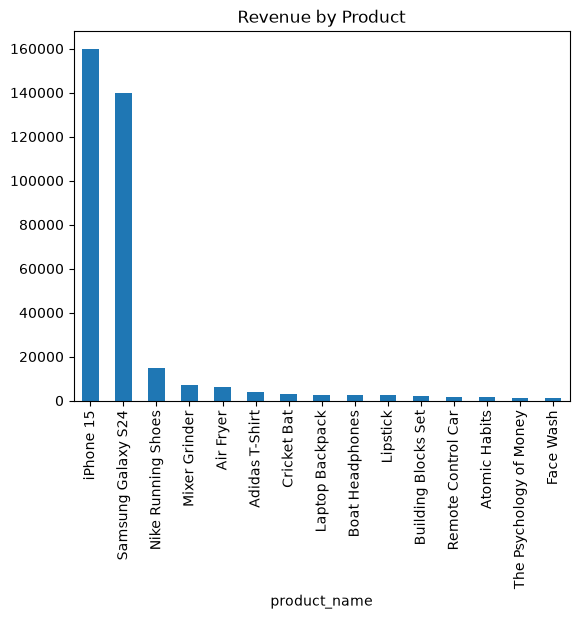

In [5]:
product_revenue.plot(
    kind="bar"
)
plt.title(
    "Revenue by Product"
)
plt.show()

In [6]:
category_revenue = (
    merged.groupby(
        "category"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

category_revenue

category
Electronics       302495.0
Sports             17996.0
Home & Kitchen     12997.0
Fashion             6596.0
Beauty              3593.0
Toys                3497.0
Books               2694.0
Name: revenue, dtype: float64

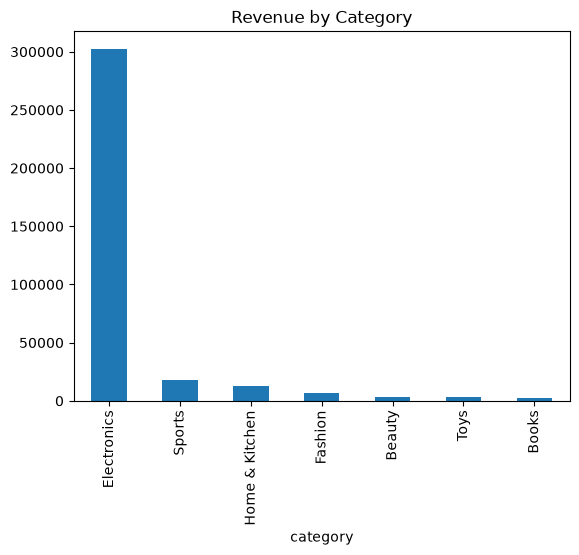

In [7]:
category_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue by Category"
)

plt.show()

In [8]:
best_selling = (
    merged.groupby(
        "product_name"
    )["quantity"]
    .sum()
    .sort_values(
        ascending=False
    )
)

best_selling

product_name
Face Wash                  4
Atomic Habits              3
Lipstick                   3
Nike Running Shoes         3
The Psychology of Money    3
Building Blocks Set        2
Adidas T-Shirt             2
Mixer Grinder              2
Samsung Galaxy S24         2
iPhone 15                  2
Laptop Backpack            2
Cricket Bat                1
Boat Headphones            1
Air Fryer                  1
Remote Control Car         1
Name: quantity, dtype: int64

In [10]:
sales_day = (
    merged.groupby(
        "day_name"
    )["revenue"]
    .sum()
)
sales_day

day_name
Friday         8497.0
Monday         4397.0
Saturday      73494.0
Sunday         8998.0
Thursday      17595.0
Tuesday      153693.0
Wednesday     83194.0
Name: revenue, dtype: float64

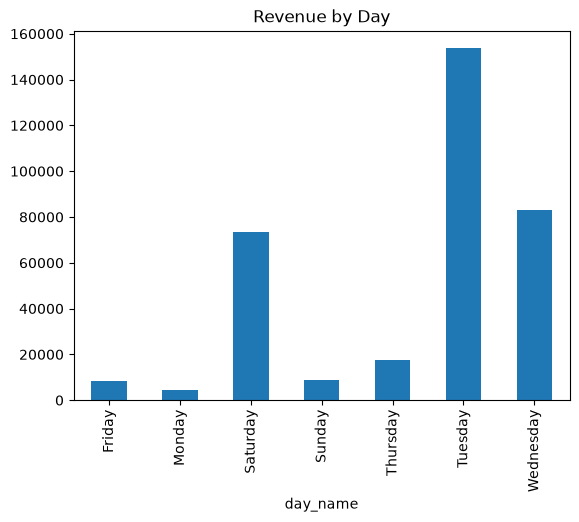

In [11]:
sales_day.plot(
    kind="bar"
)

plt.title(
    "Revenue by Day"
)

plt.show()

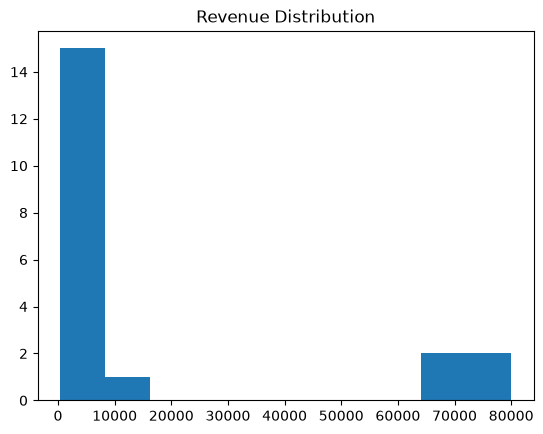

In [12]:
plt.hist(
    merged["revenue"],
    bins=10
)

plt.title(
    "Revenue Distribution"
)

plt.show()

In [13]:
customer_revenue = (
    merged.groupby(
        "customer_id"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)

customer_revenue.head()

customer_id
1     79999.0
11    79999.0
5     69999.0
17    69999.0
19     9998.0
Name: revenue, dtype: float64

In [14]:
sales_payment = (
    orders.merge(
        payments,
        on="order_id"
    )
)

In [15]:
payment_analysis = (
    sales_payment.groupby(
        "payment_method"
    )["amount"]
    .sum()
)

payment_analysis

payment_method
Card           158090.0
Net Banking      6998.0
UPI            180283.0
Wallet           4497.0
Name: amount, dtype: float64

In [16]:
numeric_columns = merged[
    [
        "quantity",
        "price",
        "revenue"
    ]
]

numeric_columns.corr()

,quantity,price,revenue
quantity,1.000000,-0.375691,-0.360159
price,-0.375691,1.000000,0.999240
revenue,-0.360159,0.999240,1.000000


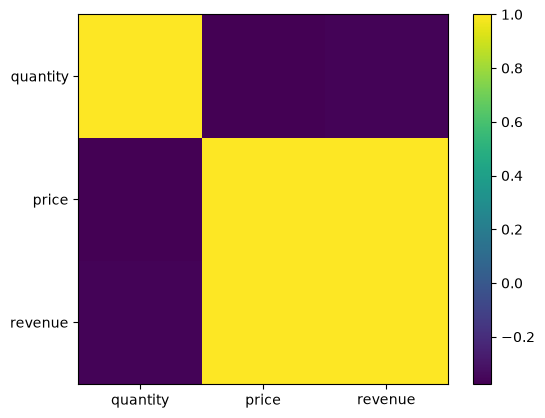

In [17]:
corr = numeric_columns.corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()